# Assignment 2 — Keras MNIST Classifier

**DATAX504** · Due end of Week 4

## Tasks
1. Dense classifier on MNIST — test accuracy **without** dropout
2. Same architecture **with** dropout — compare train vs val curves
3. Confusion matrix → worst confused digit pair
4. Explain why `sparse_categorical_crossentropy` is appropriate

## Moodle fields
`a2_repo`, `a2_test_acc`, `a2_test_acc_do`, `a2_worst_pair`, `a2_crossentropy`

## AI disclosure

Fill in before submission (see Assignment 1 template).

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import keras
from keras import layers

In [11]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## 1. Load MNIST

In [12]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

num_classes = 10
print(x_train_flat.shape, y_train.shape)

(60000, 784) (60000,)


## 2. Validation split

In [13]:
val_samples = 10000
x_val = x_train_flat[:val_samples]
y_val = y_train[:val_samples]
x_train_flat = x_train_flat[val_samples:]
y_train = y_train[val_samples:]

print("Train:", x_train_flat.shape[0], "Val:", x_val.shape[0], "Test:", x_test_flat.shape[0])

Train: 50000 Val: 10000 Test: 10000


## 3. Model builder

TODO: adjust hidden units if needed. Keep architecture comparable between runs.

In [14]:
def build_model(use_dropout=False, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
    ])
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## 4. Train baseline (no dropout)

In [9]:
EPOCHS = 20
BATCH_SIZE = 128

model_baseline = build_model(use_dropout=False)
history_baseline = model_baseline.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

test_loss, test_acc = model_baseline.evaluate(x_test_flat, y_test, verbose=0)
print(f"Baseline test accuracy (Moodle a2_test_acc): {test_acc:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9198 - loss: 0.2762 - val_accuracy: 0.9564 - val_loss: 0.1425
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9684 - loss: 0.1030 - val_accuracy: 0.9665 - val_loss: 0.1106
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9795 - loss: 0.0651 - val_accuracy: 0.9701 - val_loss: 0.1023
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9854 - loss: 0.0446 - val_accuracy: 0.9751 - val_loss: 0.0878
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9898 - loss: 0.0324 - val_accuracy: 0.9762 - val_loss: 0.0820
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9919 - loss: 0.0243 - val_accuracy: 0.9783 - val_loss: 0.0814
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9953 - loss: 0.0153 - val_accuracy: 0.9763 - val_loss: 0.0974
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9943 - loss: 0.0173 - val_accu

## 5. Train with dropout

In [15]:
model_dropout = build_model(use_dropout=True, dropout_rate=0.3)
history_dropout = model_dropout.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

_, test_acc_do = model_dropout.evaluate(x_test_flat, y_test, verbose=0)
print(f"Dropout test accuracy (Moodle a2_test_acc_do): {test_acc_do:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9179 - loss: 0.2746 - val_accuracy: 0.9585 - val_loss: 0.1362
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9695 - loss: 0.1021 - val_accuracy: 0.9719 - val_loss: 0.0906
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9792 - loss: 0.0658 - val_accuracy: 0.9765 - val_loss: 0.0766
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9853 - loss: 0.0467 - val_accuracy: 0.9760 - val_loss: 0.0778
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9886 - loss: 0.0352 - val_accuracy: 0.9807 - val_loss: 0.0736
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9911 - loss: 0.0283 - val_accuracy: 0.9739 - val_loss: 0.0841
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9929 - loss: 0.0228 - val_accuracy: 0.9798 - val_loss: 0.0743
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9941 - loss: 0.0175 - val_accu

## 6. Compare learning curves

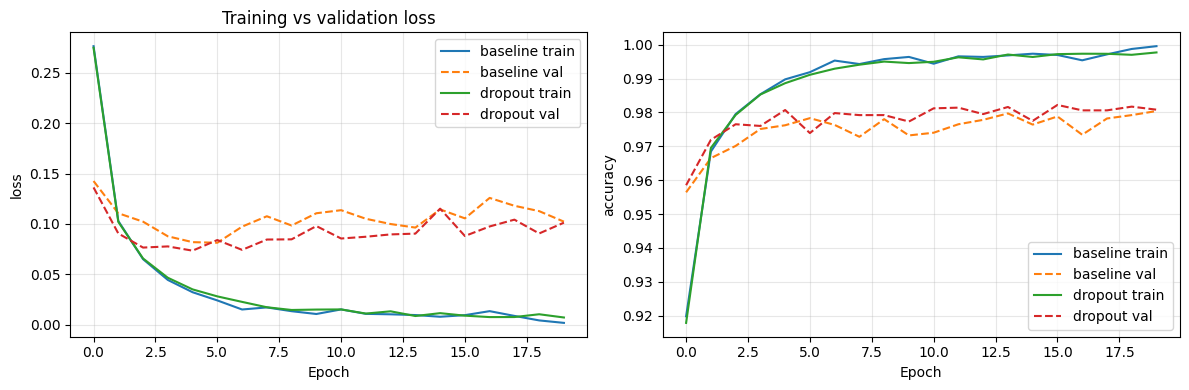

In [16]:
def plot_histories(histories, labels, metric="loss"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for hist, label in zip(histories, labels):
        axes[0].plot(hist.history[metric], label=f"{label} train")
        axes[0].plot(hist.history[f"val_{metric}"], linestyle="--", label=f"{label} val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel(metric)
    axes[0].legend()
    axes[0].set_title(f"Training vs validation {metric}")
    axes[0].grid(True, alpha=0.3)
    # accuracy panel
    for hist, label in zip(histories, labels):
        axes[1].plot(hist.history["accuracy"], label=f"{label} train")
        axes[1].plot(hist.history["val_accuracy"], linestyle="--", label=f"{label} val")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories([history_baseline, history_dropout], ["baseline", "dropout"])

## 7. Confusion matrix

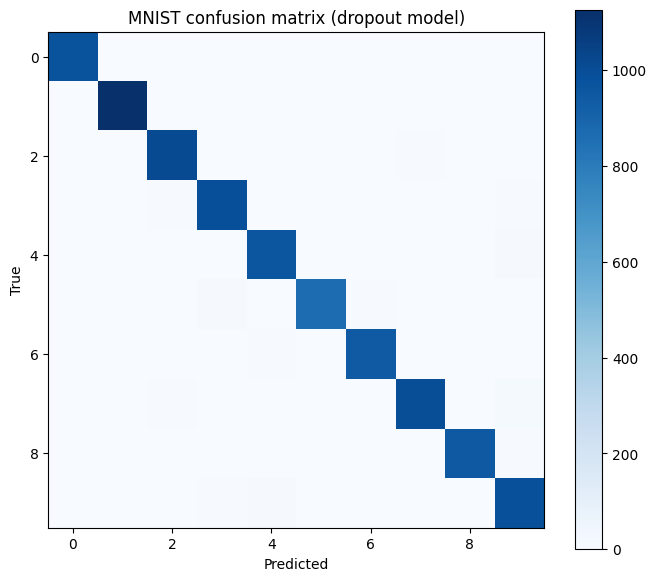

Worst confused pair (Moodle a2_worst_pair): 7-9 (14 errors)


In [17]:
y_pred = np.argmax(model_dropout.predict(x_test_flat, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("MNIST confusion matrix (dropout model)")
plt.show()

# TODO: find off-diagonal maximum → worst pair for Moodle a2_worst_pair
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
true_i, pred_j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
print(f"Worst confused pair (Moodle a2_worst_pair): {true_i}-{pred_j} ({cm_off[true_i, pred_j]} errors)")

## 8. Why sparse categorical crossentropy? (Moodle `a2_crossentropy`)

Write up to 150 words explaining:
- What integer labels look like vs one-hot
- What the loss computes
- Why this pairs with a softmax output


sparse_categorical_crossentropy is suitable for the MNIST dataset because the labels are given as whole numbers from 0 to 9. For example, an image of the number 5 has the label 5. With one-hot encoding, the same label would be represented as [0,0,0,0,0,1,0,0,0,0]. Sparse categorical crossentropy allows us to use the integer labels directly without converting them into one-hot vectors. The loss measures how close the model's prediction is to the correct class. If the model gives a high probability to the correct digit, the loss is low. If it gives a low probability, the loss is higher. This works well with the softmax output because softmax gives a probability for each of the 10 digits, with all probabilities adding up to 1.